<h1 style="font-size: 40px; margin-bottom: 0px;">5.2 Python image analysis (II)</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 800px;"></hr>

In notebook 5-1, we started exploring how images are represented on our computers by playing around with them in Python. Today, we'll take what we know about how images are represented to extract quantitative information from our images and use that information to analyze our images to derive biological insights. First, we'll load in the single set of serum-starved and serum-stimulated cells that we worked with in in notebook 5-1, then run through an analysis to quantify the nuclear intensity of YAP after serum stimulation. Then, you'll use what you learned to determine if there is a significant difference in YAP nuclear localization. 

<strong>Learning objectives:</strong>
<ul>
    <li>Continue exploring images in Python</li>
    <li>Extract quantitative information from images</li>
    <li>Analyze a single image</li>
    <li>Run a quick analysis to compare serum starved and serum stimulated conditions</li>
</ul>

In [1]:
#Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import os
import skimage as ski
import scipy.ndimage as ndi

<h1 style="font-size: 40px; margin-bottom: 0px;">Extract quantitative information from images</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 850px;"></hr>

To get us started for today's lesson, let's copy over our code to load in our image files in our <code>data</code> subdirectory like we did in notebook 5-1.

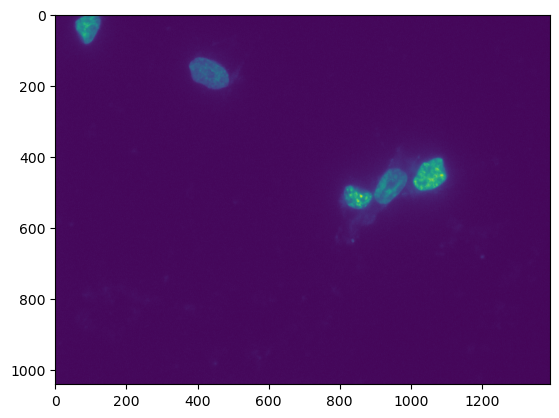

In [8]:
#We can load in our files the same way we did in notebook 5-1 since we're working with the same images
no_serum_names = [name for name in os.listdir('./data') if 'no-serum' in name]
no_serum_names.sort()

serum_names = [name for name in os.listdir('./data') if 'no-serum' not in name]
serum_names.sort()

no_serum = [plt.imread(f'./data/{i}') for i in no_serum_names]
serum = [plt.imread(f'./data/{i}') for i in serum_names]

plt.imshow(
    no_serum[0],
)

<h2>Plot the intensity profile</h2>

Since our images are 2D arrays, we can pull out rows and columns and then plot the resulting intensities along that axis as a line plot to visualize the intensity profile. Select an image from the ones that we've imported, and then see if you can plot an intensity profile by pulling out the intensity values for just a single row or a single column from that image.

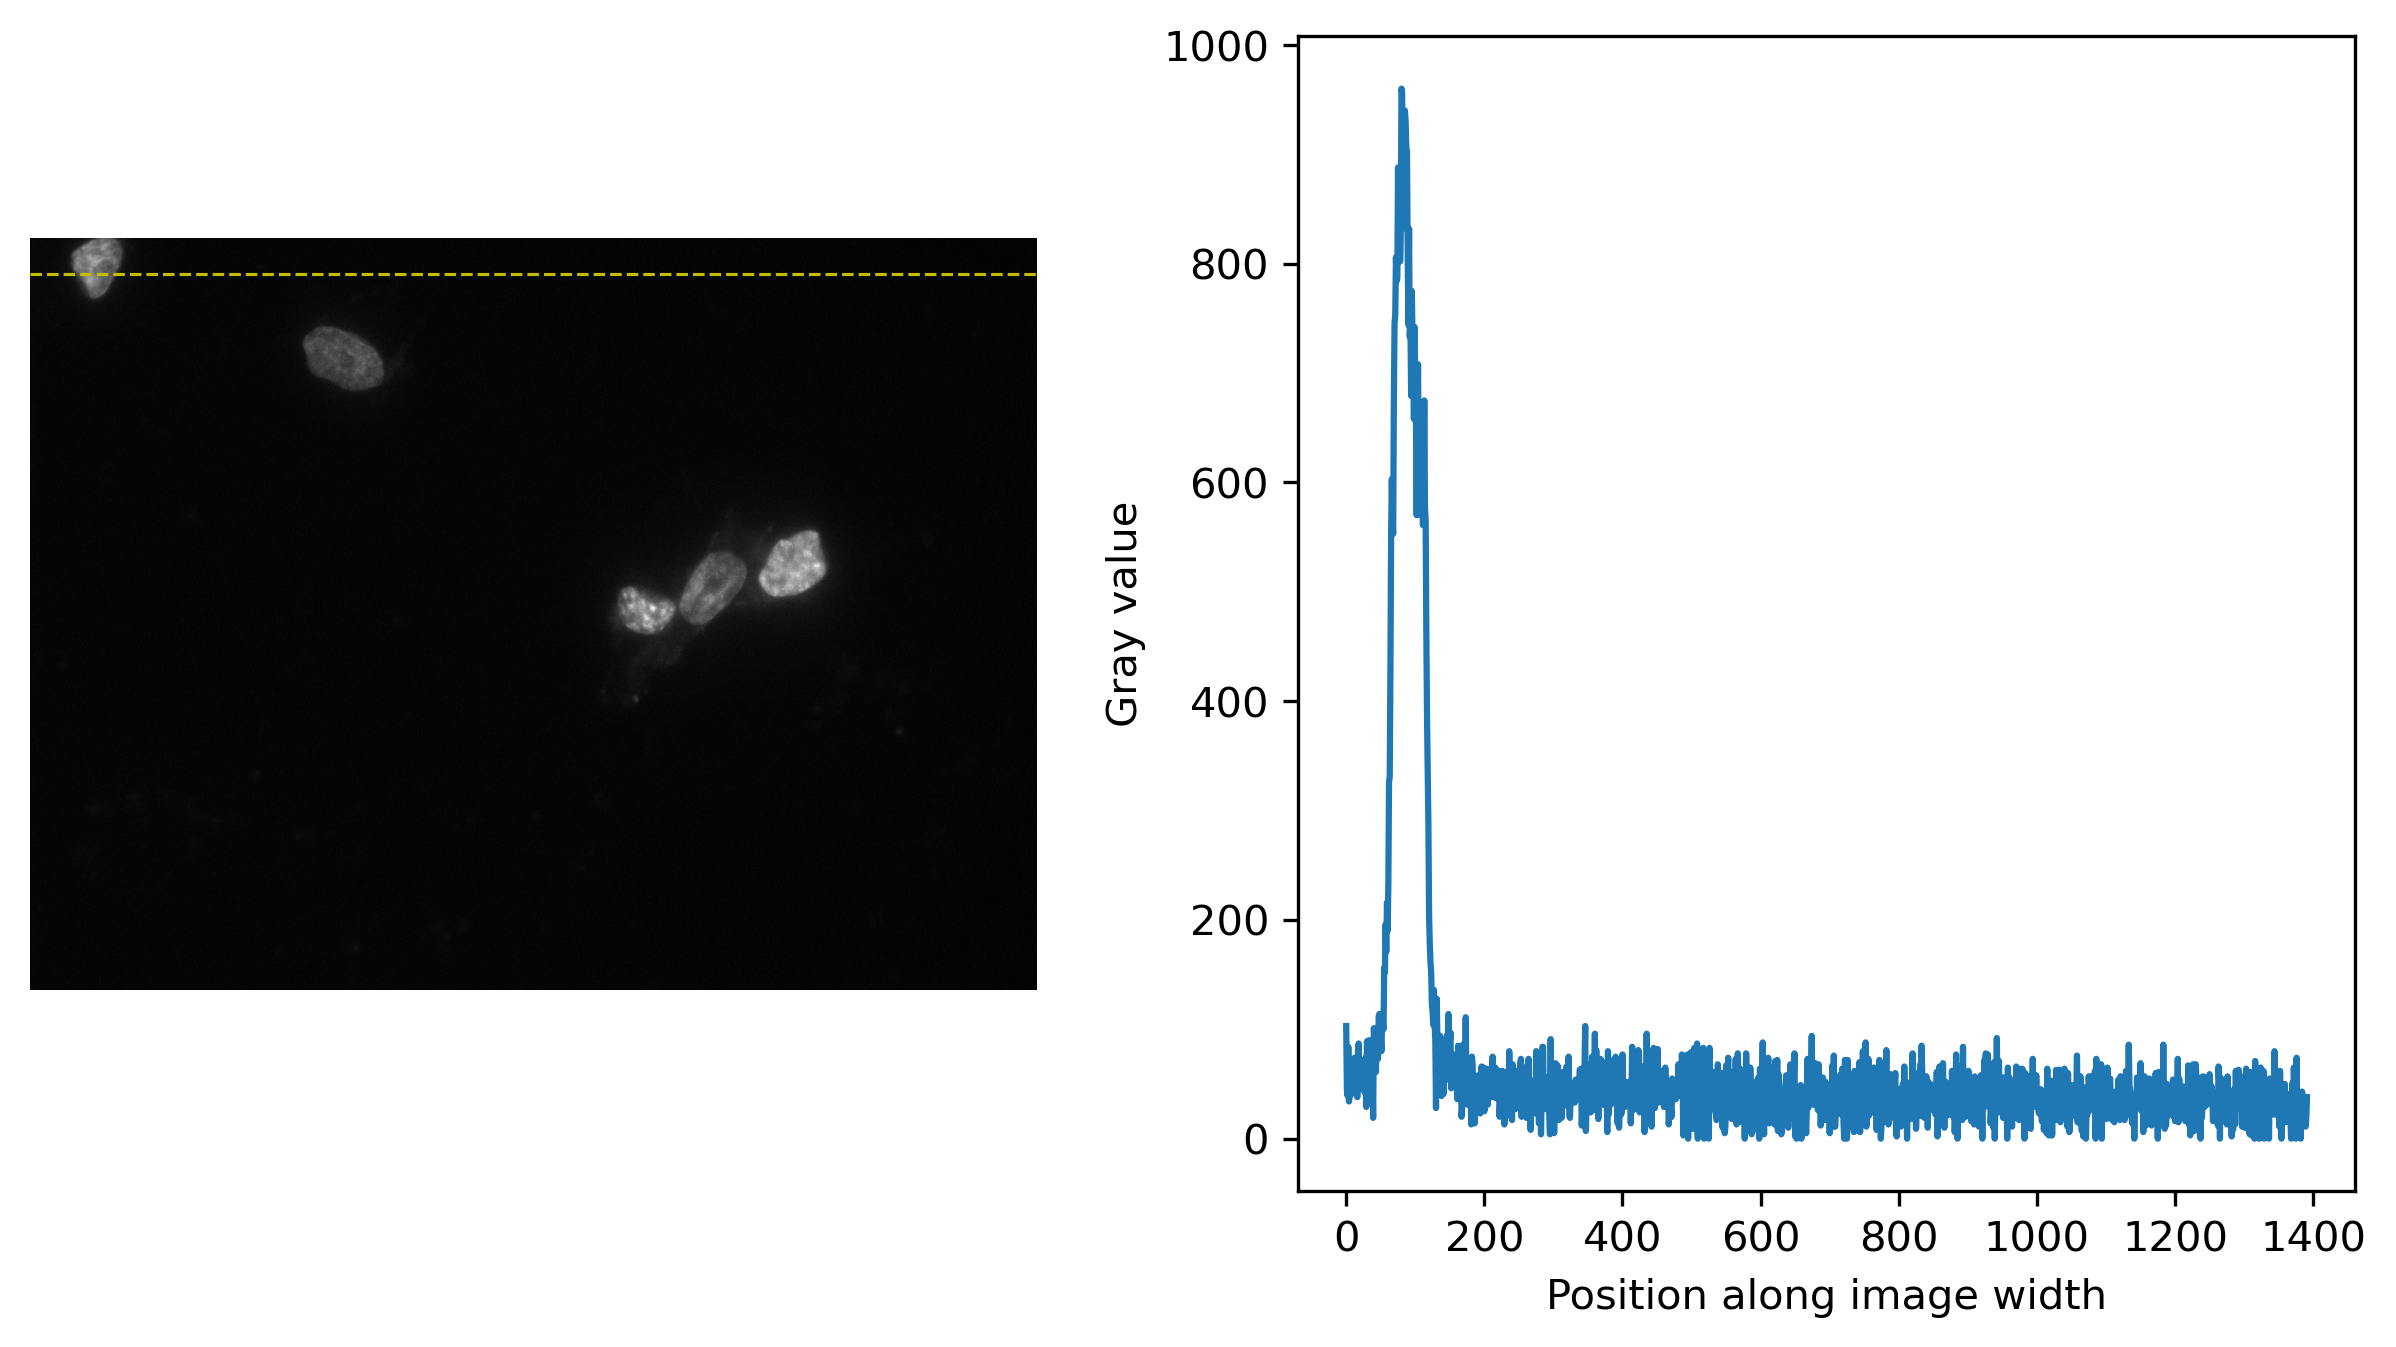

In [20]:
#Here, we're pulling out the intensity values for a single row and then plotting a line plot of it
#So the x-axis will be the position along the image's width
#and the y-axis will be the intensity value (gray value)
#To help with visualization, we'll visualize our image on the left plot
#and our lineplot on the right plot
fig, ax = plt.subplots(1, 2)

#We set up a variable to specify what row index we want to pull out
#So we can update this variable and the rest of the code will update appropriately
pull_row = 50

#Our left hand plot will just be our image
ax[0].imshow(
    no_serum[0],
    cmap='gray',
)

#And we can plot a horizontal line to show what row we're plotting
ax[0].hlines(
    pull_row,
    0,
    len(no_serum[0][pull_row, :]),
    color='y',
    ls='--',
    lw=0.75,
)

ax[0].axis(False)

#And then plot our line plot of the gray values on the right
sns.lineplot(
    no_serum[0][pull_row, :],
    ax=ax[1],
)

ax[1].set_xlabel('Position along image width')
ax[1].set_ylabel('Gray value')

fig.set_size_inches(10, 5)
fig.set_dpi(300)
plt.show()

<h2>Detect edges</h2>

The quantitative values of our images can be used to determine where edges exist in our images, and we can make use of scikit-image's <code>ski.feature.canny()</code> edge detector function to identify where the edges are. <a href="https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.canny" rel="noopener noreferrer"><u>Documentation for <code>ski.feature.canny()</code> can be found here.</u></a>

This function allows us to set the thresholds for what is considered an edge as well as smooth out noise if our images are noisy, resulting in edges being detected where they don't actually exist.

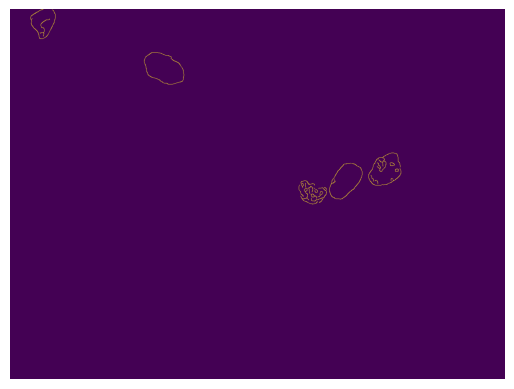

In [25]:
#From the profile plot above, we can see that edges can be identified by a large delta gray value
#Here, we use a scikit-image package to detect edges, which uses this concept
edges = ski.feature.canny(
    no_serum[0],
    sigma=1.75,
    low_threshold=100,
    high_threshold=450,
)

plt.imshow(edges)
plt.axis(False);

<h2>Identify particles in an image</h2>

Like with ImageJ, we can also create a binary image to then analyze the properties of the particles selected by our threshold. To do this, let's first process our two DAPI images again to convert our image into a binary image by thresholding. Use the same threshold for both images, so that we are processing both sample conditions in the same way. If there are holes left after thresholding, see if you remember how to fill holes in a binary image from notebook 5-1.

In [29]:
#Set up our threshold like we've done before and fill in holes
ns_thresh = no_serum[0] > 400
ns_thresh_fill = ndi.binary_fill_holes(ns_thresh)

s_thresh = serum[0] > 400
s_thresh_fill = ndi.binary_fill_holes(s_thresh)

Take a look at both thresholded DAPI images side by side.

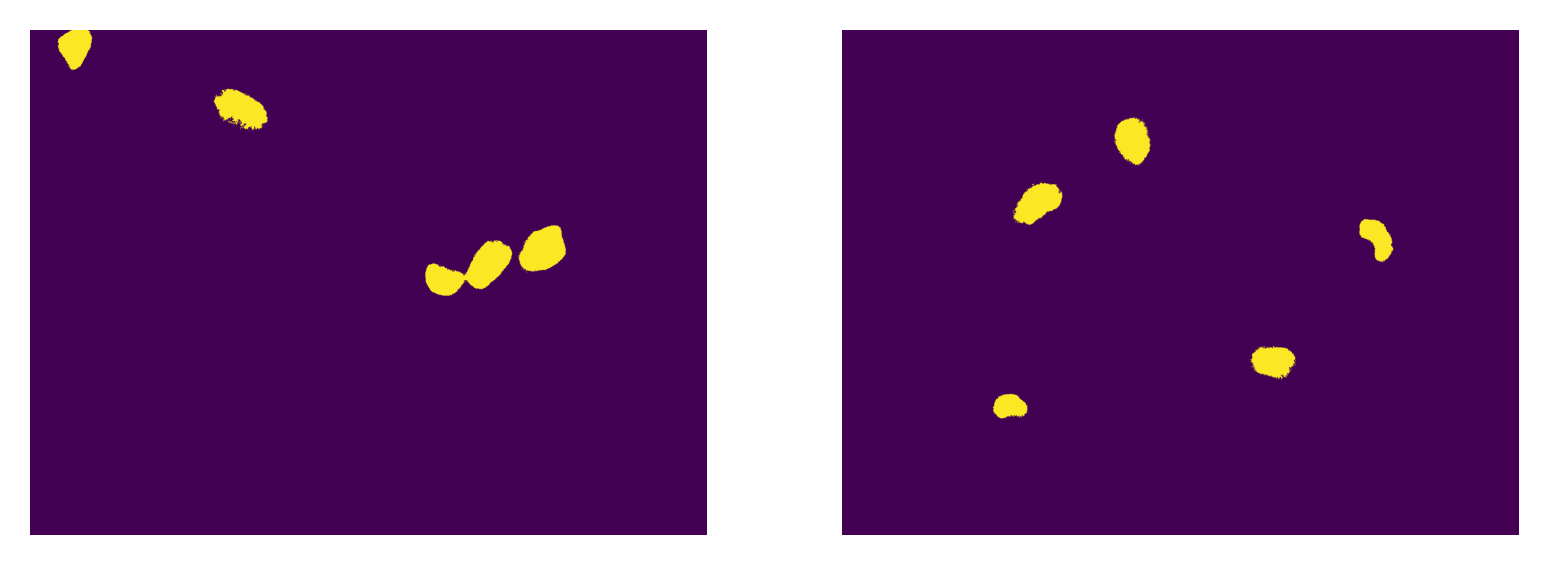

In [31]:
fig, ax = plt.subplots(1, 2)

ax[0].imshow(
    ns_thresh_fill,
)

ax[1].imshow(
    s_thresh_fill,
)

ax[0].axis(False)
ax[1].axis(False)

fig.set_dpi(300)

<h3>Remove particles on the image edge</h3>

Sometimes it can be helpful to also remove particles that are clipped by the boundaries of our image so that we exclude them from our analysis. In one of our images, we can see that there is a nucleus that is right on the edge. This could potentially throw off our results since we're not capturing the full nucleus. We can remove this particle by using <code>ski.segmentation.clear_border()</code>, which will remove particles that tough the edges of our image and is similar to what you can also do in ImageJ. <a href="https://scikit-image.org/docs/stable/api/skimage.segmentation.html#skimage.segmentation.clear_border" rel="noopener noreferrer"><u>Documentation for <code>ski.segmentation.clear_border()</code> can be found here.</u></a>

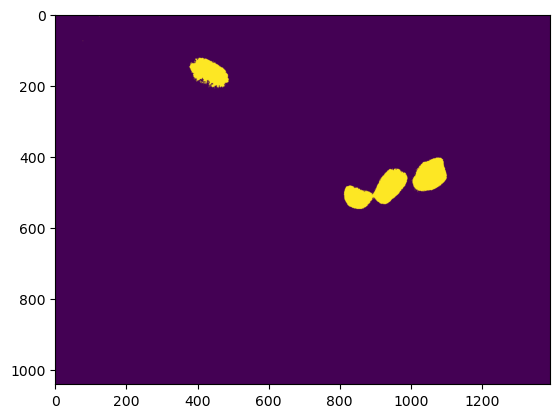

In [32]:
ns_thresh_fill = ski.segmentation.clear_border(ns_thresh_fill)

plt.imshow(ns_thresh_fill)

Once we have our processed binaries, we can use scikit-image's <code>ski.measure.label()</code> function to identify and also label individual particles in our thresholded images. <a href="https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.label" rel="noopener noreferrer"><u>Documentation for <code>ski.measure.label()</code> can be found here.</u></a>

Digging into the documentation, we can see that this function works by assigning any element in our 2D matrix with the value <code>0</code> as background pixels by default, and then it identifies particles as clusters of connected elements that share the same value, which in our case is <code>1</code>. Then after it identifies particles, it will assign each particle its own integer label.

If we dig into the documentation, we can see that it returns to us one object by default (<code>labels</code>), which is the labeled array where each particle is assigned an integer value. We can also instruct it to return an additional object (<code>num</code>), which is just the total particle count if we switch the parameter <code>return_num</code> from <code>False</code> to <code>True</code>.

In [33]:
#Here we're just labeling particles in our image
#So anything that is not background (not 0) will be a particle
#And the documentation details how it determines what a particle is
ns_label, ns_particle_count = ski.measure.label(
    ns_thresh_fill,
    return_num=True,
)

s_label, s_particle_count = ski.measure.label(
    s_thresh_fill,
    return_num=True,
)

Now let's take a look at the two objects it's returned to us. How many particles do you see when looking at the number of particles compared to how many particles you see when you visualize the returned array using <code>plt.imshow()</code>?

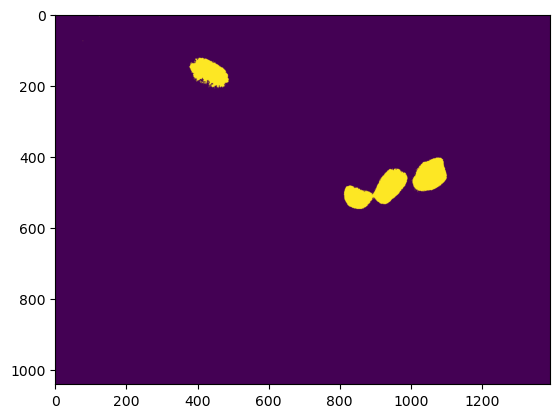

In [36]:
plt.imshow(ns_thresh_fill)

In [35]:
print(ns_particle_count)

44


<h3>Visualize labeled particles more distinctly</h3>

We can see that the particles are visualized with slightly different color if we use the viridis colormap because their labels are treated as intensity values. But we can make their colors more distinct from one another based on their labels. 

To do this, we can assign a color to each particle based on their label using <code>ski.color.label2rgb()</code>, which will allow us to more easily differentiate each particle based on their assigned color rather than treating their label as an intensity value. <a href="https://scikit-image.org/docs/stable/api/skimage.color.html#skimage.color.lab2rgb" rel="noopener noreferrer"><u>Documentation for <code>ski.color.label2rgb()</code> can be found here.</u></a>

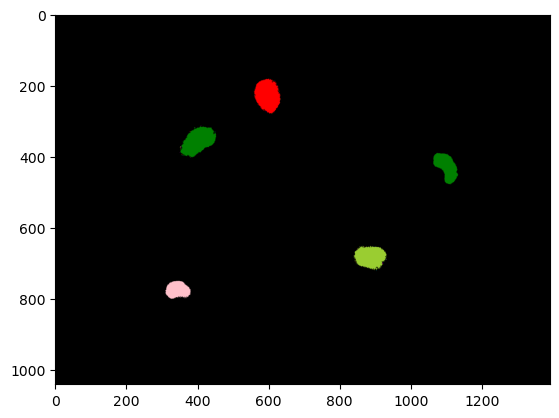

In [39]:
plt.imshow(ski.color.label2rgb(s_label))

<h2>Analyze particles</h2>

With our labeled particles, we can continue to make use of scikit-image to now analyze the labeled particles. To do this, we'll use the <code>ski.measure.regionprops()</code> function, which will measure a bunch of properties of each labeled particle. <a href="https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops" rel="noopener noreferrer"><u>Documentation for <code>ski.measure.regionprops()</code>, including the full set of properties that it measures, can be found here.</u></a>

Let's use this function to analyze our labeled particles from our serum and no serum conditions, and then save each resulting output to a new variable. 

In [40]:
ns_properties = ski.measure.regionprops(ns_label)
s_properties = ski.measure.regionprops(s_label)

Now let's take a look at the resulting object that we have as a result of this function:

In [41]:
print(ns_properties)
#We can see that the obect returned to us by the function is a list containing a bunch of RegionProperties objects
#Each elemnt in the list corresponds to an analyzed particle

[<skimage.measure._regionprops.RegionProperties object at 0x7d8db0ac5bd0>, <skimage.measure._regionprops.RegionProperties object at 0x7d8db0aabf90>, <skimage.measure._regionprops.RegionProperties object at 0x7d8db0ac5cd0>, <skimage.measure._regionprops.RegionProperties object at 0x7d8db0ac5dd0>, <skimage.measure._regionprops.RegionProperties object at 0x7d8db0ac5ed0>, <skimage.measure._regionprops.RegionProperties object at 0x7d8db0ac6010>, <skimage.measure._regionprops.RegionProperties object at 0x7d8db0ac6110>, <skimage.measure._regionprops.RegionProperties object at 0x7d8db0ac6210>, <skimage.measure._regionprops.RegionProperties object at 0x7d8db0ac6310>, <skimage.measure._regionprops.RegionProperties object at 0x7d8db0ac5fd0>, <skimage.measure._regionprops.RegionProperties object at 0x7d8db0ac64d0>, <skimage.measure._regionprops.RegionProperties object at 0x7d8db0ac65d0>, <skimage.measure._regionprops.RegionProperties object at 0x7d8db0ac66d0>, <skimage.measure._regionprops.RegionP

We can see that we were returned a compound data type in which each element within the list is a RegionProperties object corresponding to a labeled particle that was analyzed. If we dig into the documentation for <code>ski.measure.regionprops()</code>, we can see under Notes that there are a bunch of properties that can be access as attributes or keys. These include <code>area</code> and <code>label</code>, which are most relevant to our analysis today.

Let's pull out these two attributes for a random particle that we analyzed to take a look.

In [43]:
print(ns_properties[0].area)

1.0


<h3>Pull particle areas</h3>

You can see that we're able to access the quantified area of each particle by the <code>area</code> attribute, and if we wanted to then pull together all the areas of our analyzed particles, we can iterate through our list of <code>RegionProperties</code> objects that was outputed by the <code>ski.measure.regionprops()</code> function, and then specifically pull out the <code>area</code> attribute from the object.

In [45]:
#Taking a look at the number of analyzed particles for each DAPI image
print(ns_particle_count, s_particle_count)
#Can see the numbers are not equal, so we will need to set up separate for-loops

44 50


In [47]:
ns_areas = np.zeros(ns_particle_count)
s_areas = np.zeros(s_particle_count)

for i in range(0, ns_particle_count):
    ns_areas[i] = ns_properties[i].area

for j in range(0, s_particle_count):
    s_areas[j] = s_properties[j].area

Let's take a look at the measured areas for each of our particles as a single DataFrame that holds the data for both serum and no serum conditions.

In [50]:
area_data = pd.DataFrame(
    [ns_areas, s_areas],
    index=['no_serum', 'serum'],
).T

area_data

,no_serum,serum
0,1.0,5207.0
1,1.0,1.0
2,5779.0,1.0
3,1.0,1.0
4,1.0,1.0
5,1.0,1.0
6,1.0,2.0
7,1.0,1.0
8,1.0,1.0
9,4.0,1.0


<h3>Filter out noise</h3>

We can see that there are a lot of particles with just a size of 1 or are otherwise very small. This tells us that potentially, our thresholding picked up some noise as well. Let's take a look at the distribution of our particle areas.

<Axes: xlabel='no_serum', ylabel='Count'>

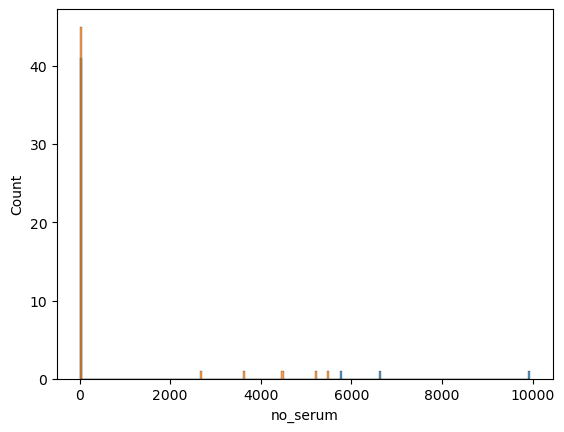

In [51]:
#We can plot a histogram of the distribution of particle areas
sns.histplot(area_data.no_serum, bins=np.arange(0, 10000, 50))
sns.histplot(area_data.serum, bins=np.arange(0, 10000, 50))

#You can then see that most particles are very small in size and thus are not nuclei
#So we need to filter these particles out before we perform our analysis

You can see that we have a fair number of tiny tiny particles with an area of less than 100 sq pixels, which probably correspond to noise (since we wouldn't expect our nuclei to be that small). So this isn't something we want to include in our analysis. So then we need to filter out these particles to remove them from our analysis. We can make use of a conditional statement to filter out these particles based on whether or not their area meets our threshold to not be considered noise.

For those of you working aheaad, what this essentially looks like is that we need to first set up a new "blank" image using <code>np.zeros_like()</code>. And then we will iterate through each <code>RegionProperties</code> object to transfer any particle whose measured <code>area</code> is above our threshold of 100 pixels over to our "blank" image. We will then end up with a new image containing only particles that are greater than our size threshold.

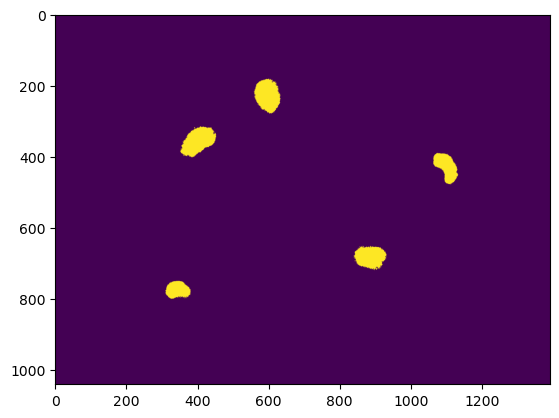

In [58]:
#To filter out noise, we first set up a new "blank" image
#which will then hold only the particles that meet our size threshold
ns_filtered = np.zeros_like(ns_label)
s_filtered = np.zeros_like(s_label)

#We loop through all the particles that were analyzed
for particle in ns_properties:
    #If the area meets our size threshold
    if particle.area > 100:
        #We "stamp" it onto our blank image and then check the next particle
        ns_filtered += ns_label == particle.label
        #If it doesn't meet the size threshold, the particle is not transferred over

#We do the same for our other DAPI image
for particle in s_properties:
    if particle.area > 100:
        s_filtered += s_label == particle.label

plt.imshow(s_filtered)

Let's take a look at our images after we filtered out the noise.

In [ ]:
#See above

Now that we've filtered out any noise, we can then relabel our particles again using <code>ski.measure.label()</code>.

In [60]:
#After filtering, we're once again left with a 2D array of booleans, so we need to relabel our particles
ns_filtered_label, ns_filtered_count = ski.measure.label(ns_filtered, return_num=True)
s_filtered_label, s_filtered_count = ski.measure.label(s_filtered, return_num=True)

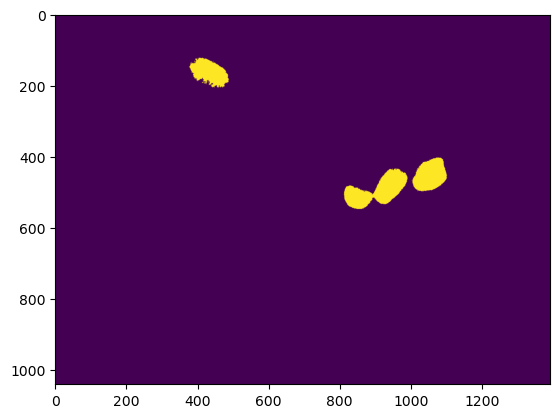

In [65]:
plt.imshow(ns_filtered)

In [63]:
#Can see now that the number of particles is reduced because we filterd out the noise
s_filtered_count

5

<h1 style="font-size: 40px; margin-bottom: 0px;">Separate particles using the watershed method</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 850px;"></hr>

For one of our images, we can see that we have two nuclei that are close together, and as a result, they end up getting labeled together as well. We can separate out these nuclei so that they are instead understood as two separate particles rather than a single particle. There are a number of different ways to computationally separate out particles, and we'll be using the watershed method, which is available as a function in scikit-image <code>ski.segmentation.watershed()</code>. <a href="https://scikit-image.org/docs/stable/api/skimage.segmentation.html#skimage.segmentation.watershed" rel="noopener noreferrer"><u>Documentation for <code>ski.segmentation.watershed()</code> can be found here.</u></a>

First, let's take a look at our filtered and relabeled image for our no serum condition. You should see that there are two nuclei close enough together that they are picked up as a single particle.

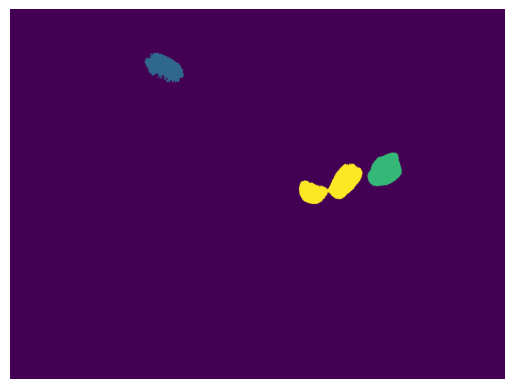

In [66]:
plt.imshow(ns_filtered_label)
plt.axis(False);
#can see for our no serum condition, there are two nuclei close together
#and as a result, they are labeled as a single particle
#So we need to separate them in order to analyze them

We'll first need to prepare our filtered and relabeled image for watershed by dilating our particles so that they are smoother, so the watershed function doesn't mistake small irregularities as things to segment.

To apply a dilation to smooth out irregularities, we can make use of the <code>ski.morphology.dilation()</code> function that we used in notebook 5-1. There, we used this function as part of a process to fill holes, but here, we'll use it to smooth out the edges of our thresholded nuclei.

In [67]:
ns_dilation = ski.morphology.dilation(
    ns_filtered_label,
    footprint=np.ones((20,20)),
)

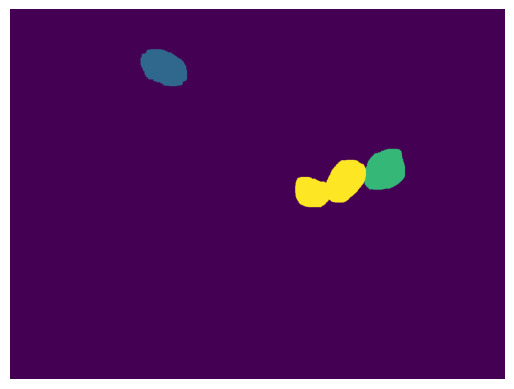

In [68]:
plt.imshow(ns_dilation)
plt.axis(False);

Then we can calculate the centers of our individual particles by calculating the distance within the particle from the edges (or background), which will give us an idea of where the center of each "true" particle should be. To do this, we'll make use of the <code>ndi.distance_transform_edt()</code> function, which calculates the Euclidean distance from the background. <a href="https://docs.scipy.org/doc//scipy-1.8.0/reference/generated/scipy.ndimage.distance_transform_edt.html" rel="noopener noreferrer"><u>Documentation for <code>ndi.distance_transform_edt()</code> can be found here.</u></a>

For those of you working ahead, pass your dilated image to the <code>ndi.distance_transform_edt()</code> function using default parameters and save the output to a new variable.

In [69]:
distance = ndi.distance_transform_edt(ns_dilation)

Let's take a look to see how the distance map looks like.

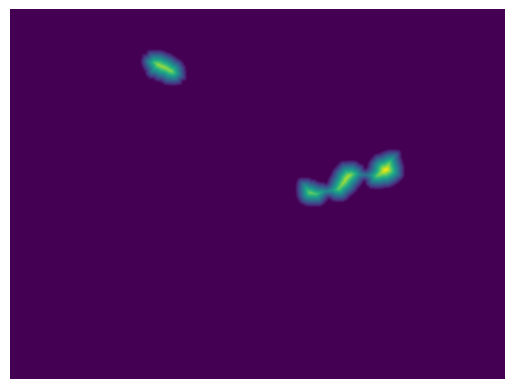

In [70]:
plt.imshow(distance)
plt.axis(False);
#You can see that the areas of the highest value are towards the centers of each nuclei
#since the function calculates the distance from the nearest edge for each pixel within the particle

You can see that the regions of greatest distance from the background now have the highest value, which we can more readily visualize with the viridis colormap. 

We can then identify the coordinates of the centers of each "true" particle by identifying where the local maxima are using the calculated distances. We'll make use of the <code>ski.feature.peak_local_max()</code> function, which will find the spots of highest value (peaks) and return their coordinates to us. <a href="https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.peak_local_max" rel="noopener noreferrer"><u>Documentation for <code>ski.feature.peak_local_max()</code> can be found here.</u></a>

For those of you working ahead, you'll need to pass your distance map to the <code>ski.feature.peak_local_max()</code> function and then pass an argument for the footprint, which determines the size of the area in which to compare the values to determine the local peak. Save the output to a variable.

In [71]:
#We can then find the coordinates of the highest points, essentially finding the center of each nucleus
coordinates = ski.feature.peak_local_max(
    distance,
    footprint=np.ones((30,30)),
)

How does the output look like?

In [73]:
coordinates.T

array([[ 452,  476,  162,  516],
       [1055,  945,  428,  843]])

The output is essentially the coordinates corresponding to where our calculated local peaks were determined to be. We can take these coordinates and set them as points in a 2D matrix matching the shape of our labeled nuclei image. These coordinates will determine where in our image we want to initiate our watershed method.

In [74]:
#We can then plot each coordinate onto a 2D array of the same dimensions
#First set up the "blank" image
mask = np.zeros_like(ns_filtered_label)

#Then plot the markers using the coordinates that we calculated
#Essentiallly flip those zeros at those coordinate positions to a 1 instead
mask[tuple(coordinates.T)] = 1

We can then add labels to each coordinate point.

In [75]:
markers, _ = ndi.label(mask)

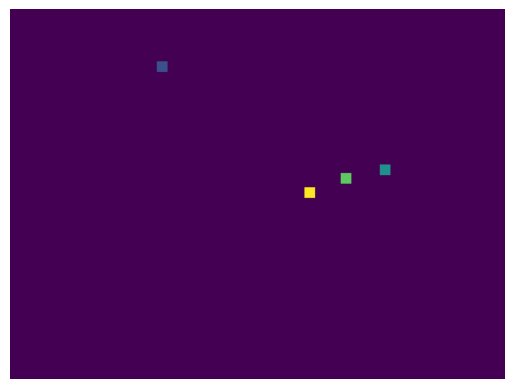

In [77]:
#Here we can just quickly visualize to see where the peaks were plotted to be
plt.imshow(ski.morphology.dilation(markers, footprint=np.ones((30,30))))
plt.axis(False);

With those coordinates set and labeled, we can then initiate the watershed using the <code>ski.segmentation.watershed()</code> function. <a href="https://scikit-image.org/docs/0.25.x/api/skimage.segmentation.html#skimage.segmentation.watershed" rel="noopener noreferrer"><u>Documentation for <code>ski.segmentation.watershed()</code> can be found here.</u></a>.

What we're doing is essentially identifying a local minimum, which we can set as the inverse of our local maxima, and then "flood" the region. We can also specify how much "flooding" we want to happen by using our original labeled nuclei as a mask.

The output from this function will be a new image with particles segmented according to the watershed method and using the coordinates and distances we calculated. Save the output to a new variable.

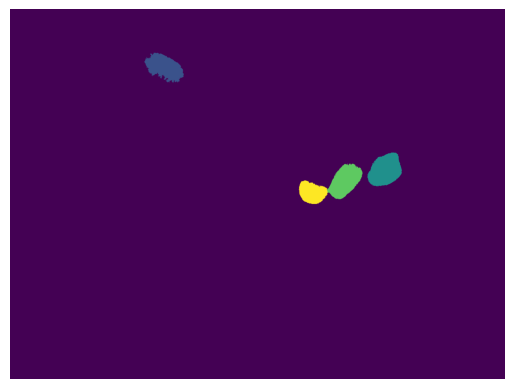

In [85]:
watersh_label = ski.segmentation.watershed(
    -distance,
    markers=markers,
    mask=ns_filtered_label,
)

plt.imshow(watersh_label)
plt.axis(False);

How does the resulting image look like now that you've segmented your nuclei?

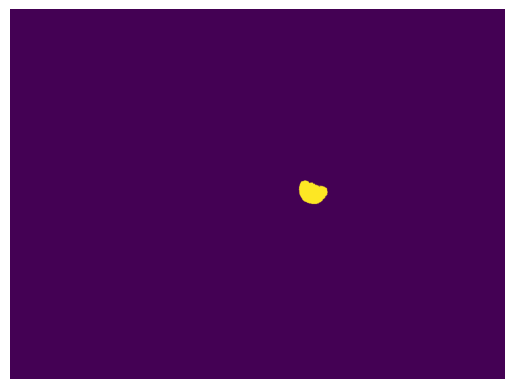

In [89]:
plt.imshow(watersh_label == 4)
plt.axis(False);

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #1: Pull out a single cell</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 850px;"></hr>

Now that we have our nuclei individually labeled, see if you can pull out a single nucleus and display a binary image of your single nucleus.

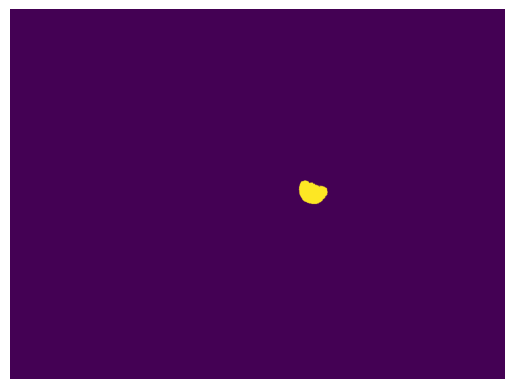

In [93]:
#We can pull out a single nucleus by its label
single_nuc = watersh_label == 4

plt.imshow(single_nuc)
plt.axis(False);

In [94]:
#Can see that after pulling out a nucleus by its label, we have a 2D array of booleans again
single_nuc

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #2: Measure mean nuclear fluorescence</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 900px;"></hr>

Now that you're able to pull out a single nucleus at a time, see if you can then quantify the mean nuclear fluorescence for a single nucleus. Recall from 5-1 how you can use binary images as a mask, which will allow you to focus on just a particular region of interest, and you can apply this mask to the YAP channel.

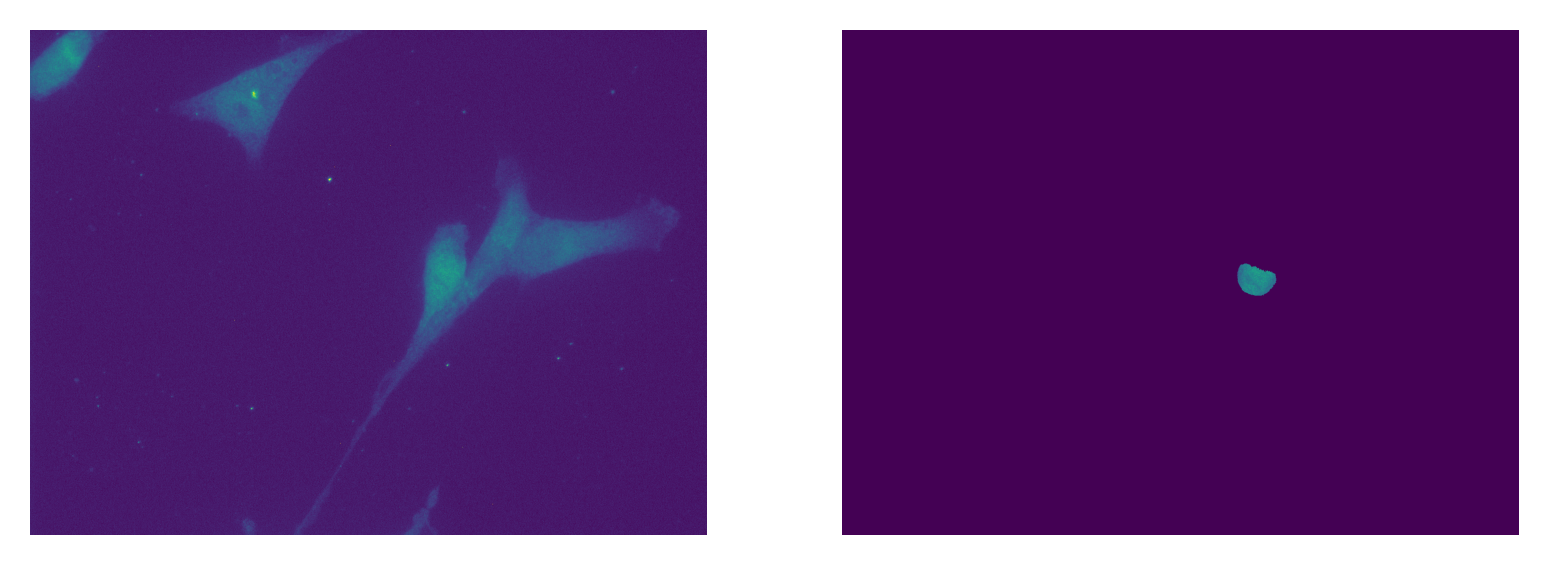

In [98]:
single_nuc = watersh_label == 4

fig, ax = plt.subplots(1,2)

ax[0].imshow(
    no_serum[2],
    vmin=0,
    vmax=800,
)

ax[1].imshow(
    no_serum[2] * single_nuc, #We can take that 2D array of booleans and use it as a mask like we did in 5-1
    vmin=0,
    vmax=800,
)

ax[0].axis(False)
ax[1].axis(False)

fig.set_dpi(300)
plt.show()

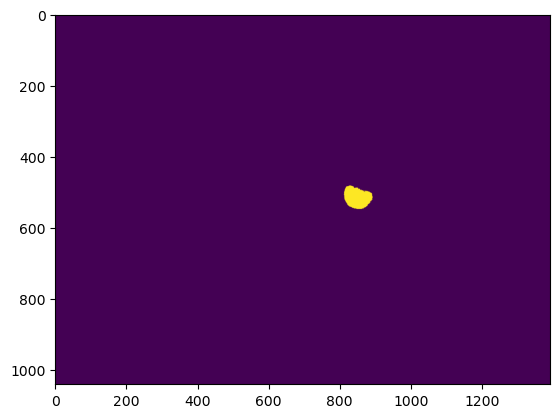

In [100]:
plt.imshow(single_nuc)

In [101]:
#Using the single nucleus as a mask, we can obtain just the green channel's intensity values for that specific nucleus
fluorescence = no_serum[2] * single_nuc

#And since all the background values are zero, we can sum the entire 2D array to get the total fluorescence
#And do the same with the 2D boolean to get the area (since all pixel values are 1)
#And the mean fluorecence is just the total fluorscence divided by the area
mean_fluorescence = np.sum(fluorescence) / np.sum(single_nuc)

mean_fluorescence

363.3836510838339

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #3: Analyze all nuclei in a single image</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 900px;"></hr>

See if you can set up a way to instead of manually analyzing a single nucleus one at a time, to analyze all the nuclei in a single image. Specifically for this exercise, see if you can analyze the mean nuclear YAP fluorescence intensity for all the nuclei in a single image, either the serum-starvation or the serum-stimulation condition.

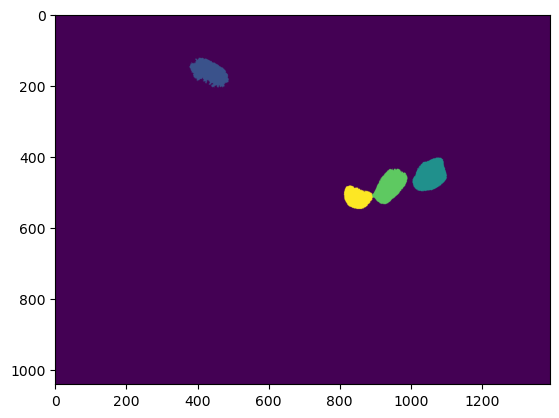

In [102]:
plt.imshow(watersh_label)

In [103]:
#We can pull out the number of particles by simply finding what the maximum label value is
watersh_label.max()

4

In [106]:
#There's two ways that we can analyze mean fluorescence intensity for all particles

#The first way is to set up a for-loop and loop through all particles and calculate it for each one
ns_mean_fl = np.zeros(watersh_label.max())

for i in range(0, watersh_label.max()):
    single_nuc = watersh_label == i + 1
    ns_mean_fl[i] = np.sum(no_serum[2] * single_nuc) / np.sum(single_nuc)

#The alternative is that we can use a function within scikit-image to calculate it for each image
#The regionprops_table() function will return to us a dictionary containing the values for different particle properties
#one of which is the 'intensity_mean' which is the mean intensity for each particle
#each particle will have its own value
ns_alternative = ski.measure.regionprops_table(
    watersh_label,                                    #We provide it with the mask
    intensity_image=no_serum[2],                      #And the channel we want the intensity values from
    properties=('label', 'area', 'intensity_mean'),   #And specify the properties we want it to give us
)

#we can take a look at the dict object as a DataFrame instead so that it's easier to read
pd.DataFrame(ns_alternative)

,label,area,intensity_mean
0,1,5729.0,260.802234
1,2,6605.0,237.771385
2,3,6102.0,223.832022
3,4,3829.0,363.383651


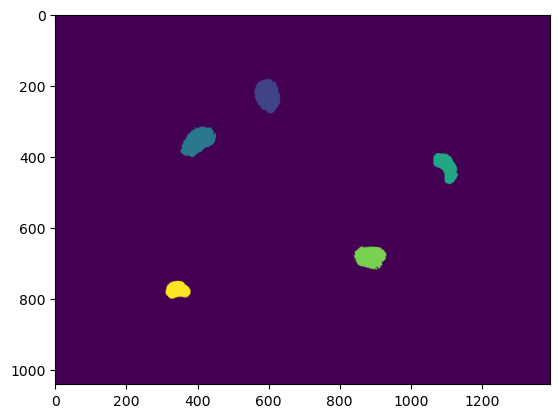

In [107]:
plt.imshow(s_filtered_label)

In [108]:
#We can use this same alternative way for our serum stim images
s_alternative = ski.measure.regionprops_table(
    s_filtered_label,
    intensity_image=serum[2],
    properties=('label', 'area', 'intensity_mean'),
)

pd.DataFrame(s_alternative)

,label,area,intensity_mean
0,1,5207.0,380.029960
1,2,5495.0,473.228753
2,3,3636.0,506.277228
3,4,4464.0,341.521281
4,5,2682.0,672.620805


<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #4: Perform statistical analysis</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 900px;"></hr>

Let's run a quick statistical analysis on our results from our single set of images.

In [109]:
results = stats.ttest_ind(
    ns_alternative['intensity_mean'],
    s_alternative['intensity_mean'],
    equal_var=False,
)

results.pvalue

0.021386324940774578

<h1 style="font-size: 40px; margin-bottom: 0px;">Challenge #1: Analyze nuclear:cytoplasmic ratio</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 900px;"></hr>

In the above examples, we looked at just the nuclear intensity and compared the intensities between our two conditions. Recall back in MCB201A, we analyzed the nuclear:cytoplasmic ratio in order to determine if there was a quantifiable difference in localization and to normalize for differences in signal intensity between different cells.

For those of you who want a challenge, see if you can take what you now know about analyzing images and apply it to the two images that we've been working with to determine if there is a significant difference in the nuclear:cytoplasmic ratio between serum-starved and serum-treated cells. Is there a way you could potentially make it more automated?

In [144]:
#We went through this together as a guided example
#We'll go over this again on Wednesday after the computational model presentations
def image_processor(red, green, blue):
    
    blue_binary = blue > 400
    blue_binary = ndi.binary_fill_holes(blue_binary)
    blue_binary = ski.segmentation.clear_border(blue_binary)
    
    label, particle_count = ski.measure.label(blue_binary, return_num=True)
    
    properties = ski.measure.regionprops(label)
    
    filtered = np.zeros_like(label)
    
    for particle in properties:
        if particle.area > 100:
            filtered += label == particle.label
    
    filtered_label, filtered_count = ski.measure.label(filtered, return_num=True)
    
    blue_process = ski.morphology.erosion(
        blue_binary,
        footprint=ski.morphology.disk(10),
    )

    blue_process = ski.morphology.dilation(
        blue_process,
        footprint=ski.morphology.disk(25),
    )

    blue_process = ski.morphology.erosion(
        blue_process,
        footprint=ski.morphology.disk(5),
    )

    distance = ndi.distance_transform_edt(blue_process)

    coordinate = ski.feature.peak_local_max(
        distance,
        min_distance=100,
        footprint=np.ones((150,150)),
    )

    mask = np.zeros_like(blue)

    mask[tuple(coordinates.T)] = 1 #We ran into an issue in class that we'll troubleshoot on Wednesday, but the issue is this extra s here in the variable coordinates.

    markers, _ = ndi.label(mask)

    blue_watershed = ski.segmentation.watershed(
        -distance,
        markers=markers,
        mask=filtered_label,
    )

    blue_watershed_labels = np.unique(blue_watershed)

    red_binary = red > ski.filters.threshold_isodata(red)
    red_binary = ndi.binary_fill_holes(red_binary)

    red_watershed = ski.segmentation.watershed(
        -distance,
        markers=markers,
        mask=red_binary,
    )

    red_watershed = red_watershed * ~( filtered_label > 0)

    red_watershed_labels = np.unique(red_watershed)

    cleaned_red_watershed = np.zeros_like(red_watershed)

    for num in red_watershed_labels:
        if num in blue_watershed_labels:
            cleaned_red_watershed += ((red_watershed == num) * num)

    nuclear_measurements = ski.measure.regionprops_table(
        blue_watershed,
        intensity_image = green,
        properties=('label', 'area', 'intensity_mean'),
    )

    cytoplasmic_measurements = ski.measure.regionprops_table(
        cleaned_red_watershed,
        intensity_image = green,
        properties=('label', 'area', 'intensity_mean'),
    )

    return nuclear_measurements, cytoplasmic_measurements

In [145]:
ns_nuc, ns_cyt = image_processor(no_serum[1], no_serum[2], no_serum[0])

print(ns_nuc, ns_cyt)

{'label': array([1, 2, 3, 4]), 'area': array([5729., 6605., 6081., 3850.]), 'intensity_mean': array([260.80223425, 237.77138531, 223.61009702, 362.97298701])} {'label': array([1, 2, 3, 4]), 'area': array([28488., 29805., 11805., 25333.]), 'intensity_mean': array([171.00473884, 158.4212045 , 183.88903007, 181.06165871])}


In [146]:
s_nuc, s_cyt = image_processor(serum[1], serum[2], serum[0])

In [147]:
s_nuc

{'label': array([], dtype=int64),
 'area': array([], dtype=float64),
 'intensity_mean': array([], dtype=float64)}

In [148]:
stats.ttest_ind(
    ns_nuc['intensity_mean']/ns_cyt['intensity_mean'],
    s_nuc['intensity_mean']/s_cyt['intensity_mean'],
    equal_var=False,
    nan_policy='omit',
).pvalue

nan